# WWWMD 1: Visualizing Soccer Tracking Data (Starter)

In [2]:
import pandas as pd
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()

Matplotlib is building the font cache; this may take a moment.


In [4]:
import os
cwd = os.getcwd()
print(cwd)

/Users/viktoriyapanahova/Desktop/Farhad/claude/study/Sports Analytics/mit_sports-analytics-github/Week 1 - Getting Started


## WWWMD 1

In [5]:
wwwmd_1 = pd.read_csv(cwd + '/soccer_tracking.csv')
wwwmd_1.head()

,x_loc,y_loc
0,-25.068582,-1.200835
1,21.873093,11.591569
2,-45.467515,-18.187860
3,-44.135945,16.480717
4,-25.890514,21.005973


In [7]:
wwwmd_1.describe().T

,count,mean,std,min,25%,50%,75%,max
x_loc,1000.0,-6.273198,37.479381,-59.682838,-39.903768,-11.518090,22.267907,59.878799
y_loc,1000.0,-5.522152,24.189889,-39.787095,-31.708293,1.026137,12.437967,39.367066


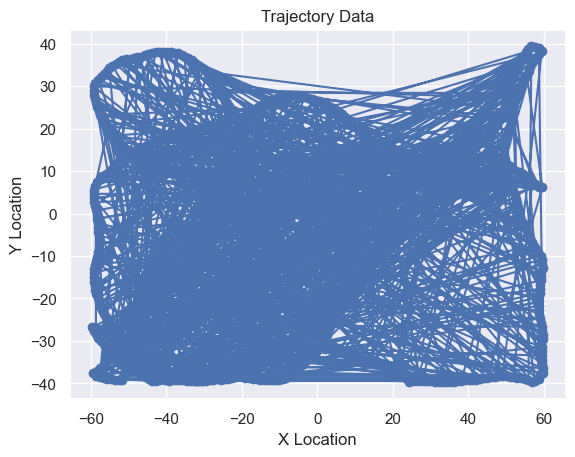

In [6]:
plt.plot(wwwmd_1['x_loc'], wwwmd_1['y_loc'],'o-')
plt.xlabel('X Location')
plt.ylabel('Y Location')
plt.title('Trajectory Data')
plt.show()

In [16]:
# Calculate Euclidean distance between consecutive points
dx = wwwmd_1["x_loc"].diff()
dy = wwwmd_1["y_loc"].diff()

distances = np.sqrt(dx**2 + dy**2).dropna()

average_distance = distances.mean()
median_distance = distances.median()

relative_distance_lenght = average_distance / (wwwmd_1["x_loc"].max() - wwwmd_1["x_loc"].min())

print(f"Average distance traveled: {average_distance:.2f}")
print(f"Median distance traveled: {median_distance:.2f}")
print(f"Relative distance traveled: {relative_distance_lenght:.4f}")

Average distance traveled: 55.61
Median distance traveled: 54.05
Relative distance traveled: 0.4651


In [17]:
game_duration_seconds = 90 * 60
seconds_per_record = game_duration_seconds / len(wwwmd_1)

print(f"Seconds per record: {seconds_per_record:.2f}")

Seconds per record: 5.40


## WWWMD 1 --- SOLUTION

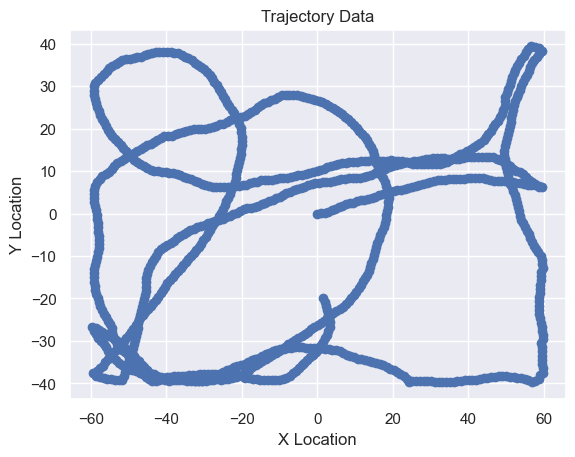

In [20]:
plt.plot(wwwmd_1['x_loc'], wwwmd_1['y_loc'], 'o')
plt.xlabel('X Location')
plt.ylabel('Y Location')
plt.title('Trajectory Data')
plt.show()

In [ ]:
# For each point, find the closest point in the remaining points in the dataset, and append the index of the closest point to the reorder_indices list
def comp_dist(point1, point2):
    # Calculate the Euclidean distance between two points
    return np.sqrt((point1['x_loc'] - point2['x_loc'])**2 + (point1['y_loc'] - point2['y_loc'])**2)

def reorder_data(df):
    df_new = df.copy()
    # Create a list to store the indices of the points in the order they should be plotted
    reorder_indices = []
    for i in range(len(df_new)):
        if i == 0:
            reorder_indices.append(i)
        else:
            # Get the index of the last point in the reorder_indices list
            last = reorder_indices[-1]
            # Initialize the minimum distance to infinity
            min_dist = float('inf')
            # Initialize the index of the point with the minimum distance to None
            min_index = None
            # Iterate over the points in the dataset
            for j in range(len(df_new)):
                if j not in reorder_indices:
                    dist = comp_dist(df_new.iloc[last], df_new.iloc[j])
                    # If the distance is less than the current minimum distance, update the minimum distance and the index of the point with the minimum distance
                    if dist < min_dist:
                        min_dist = dist
                        min_index = j
            # If the point with the minimum distance is not None, append its index to the reorder_indices list
            if min_index is not None:
                reorder_indices.append(min_index)
    # Return the points in the order they should be plotted
    return df_new.iloc[reorder_indices].reset_index(drop=True)
wwwmd_1_corrected = reorder_data(wwwmd_1)
print(wwwmd_1_corrected[:50])

        x_loc      y_loc
0  -25.068582  -1.200835
1  -26.028295  -1.481817
2  -26.624504  -1.432320
3  -26.991999  -1.748792
4  -27.258228  -2.205879
5  -27.957115  -2.010613
6  -28.905446  -2.327895
7  -29.869407  -2.593940
8  -30.818410  -2.909207
9  -31.768749  -3.220425
10 -32.707082  -3.566158
11 -33.642962  -3.918474
12 -34.554776  -4.329079
13 -35.459114  -4.755896
14 -36.273837  -5.335746
15 -37.149829  -5.818072
16 -37.977420  -6.379404
17 -38.854693  -6.859396
18 -39.747857  -7.309126
19 -40.610288  -7.815300
20 -41.397289  -8.432253
21 -42.147510  -9.093439
22 -42.726558  -9.908733
23 -43.308958 -10.721635
24 -43.928061 -11.506946
25 -44.475547 -12.343760
26 -44.921579 -13.238777
27 -45.182548 -14.204124
28 -45.308045 -15.196218
29 -45.431210 -16.188605
30 -45.429003 -17.188602
31 -45.467515 -18.187860
32 -45.665932 -19.167978
33 -45.892954 -20.141867
34 -46.198226 -21.094133
35 -46.501531 -22.047026
36 -46.851589 -22.983754
37 -47.115298 -23.948357
38 -46.940389 -24.699220


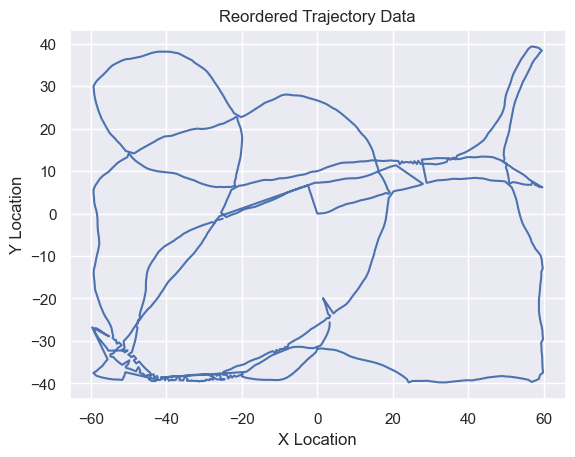

In [22]:
plt.plot(wwwmd_1_corrected['x_loc'], wwwmd_1_corrected['y_loc'])
plt.xlabel('X Location')
plt.ylabel('Y Location')
plt.title('Reordered Trajectory Data')
plt.show()